<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h2 style="margin:0; padding:8px 0;">
     Q‑Learning, SARSA, and Expected SARSA : Implementation on Grid World (Fox 2016)
  </h2>

  <h3 style="margin:0; padding:6px 0;">
    RL Group Project Part 2 : Team - Reward Hunters 
  </h3>

  <h5 style="margin:0; padding:6px 0;">
    Ejisay, Mansvi, Somesh, Vasant
  </h5>

</div>

In this notebook we implemented and compared:

1. **Q‑Learning** with ε‑greedy action selection.
2. **SARSA** (on‑policy TD control) with ε‑greedy action selection.
3. **Expected SARSA** with ε‑greedy action selection.

We evaluate their performance on the 8×8 GridWorld environment described in Fox (2016).

#### Environment details:
- **States:** 8×8 grid (indices 0…63). Terminal state is `[4,4]` (index 36).
- **Blocked (invalid) states:** 15 cells listed in `inv_state`.
- **Actions:** 9 moves – 8 compass directions + a "no change" action (index 8).
- **Step cost:** +1 plus Gaussian noise (σ = 0.2) for every step.
- If the intended move would go out of bounds or into a blocked cell:
  - The agent stays in place.
  - An extra penalty of +1000 (plus noise) is added.
- **Stochastic drift:** after every action, there is a 30% chance that the agent drifts to a neighbouring cell (uniform distribution over the 8 directions). Drift also incurs a cost of +1 (plus noise) and is subject to the same validity checks (if the drift lands out of bounds or on a blocked cell, it is reverted and the cost is undone).
- The episode ends when the agent reaches `[4,4]`. No discounting (γ = 1) unless stated otherwise.

We will run multiple independent runs, plot learning curves (cumulative cost per episode) with mean and standard deviation, examine the behaviour of all three algorithms, and perform sensitivity analyses.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# Import the provided environment
from gridworld_env import GridWorldEnv

# Check that it works
env = GridWorldEnv()
print("Environment loaded.")

GridWorldEnv (Fox2016) Loaded...
Environment loaded.


#### Helper Functions

In [3]:
def state_to_index(state):
    """Convert [row, col] to flat index 0..63."""
    return state[0] * 8 + state[1]

def index_to_state(idx):
    """Convert flat index to [row, col]."""
    return [idx // 8, idx % 8]

def is_terminal(state):
    return state[0] == 4 and state[1] == 4

NUM_STATES = 64
NUM_ACTIONS = 9

### 1. Q‑Learning Update Rule

The Q‑learning algorithm updates the action‑value function $Q(s,a)$ using the following equation:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]
$$

where:
- $Q(s,a)$ – current estimate of the value of taking action $a$ in state $s$
- $\alpha$ – learning rate (step size)
- $r$ – immediate reward received after executing action $a$
- $\gamma$ – discount factor
- $s'$ – next state
- $\max_{a'} Q(s', a')$ – maximum estimated value over all possible actions in state $s'$

When $s'$ is a terminal state, the update simplifies to:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r - Q(s, a) \big]
$$

In [5]:
class QLearningAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            max_q_next = np.max(self.q[next_idx, :])
            target = reward + self.discount * max_q_next
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_idx)
        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

### 2. SARSA Update Rule (On‑Policy)

SARSA updates the action‑value function using the action actually taken in the next state:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma Q(s', a') - Q(s, a) \Big]
$$

where $a'$ is the action chosen by the current policy (e.g., ε‑greedy) in state $s'$.  
For terminal states, the update is simply $Q(s,a) \leftarrow Q(s,a) + \alpha [r - Q(s,a)]$.

In [7]:
class SarsaAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            next_action = self.choose_action(next_idx)
            target = reward + self.discount * self.q[next_idx, next_action]
        else:
            next_action = None
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

### 3. Expected SARSA Update Rule

Expected SARSA uses the expected value over the action distribution in the next state:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \sum_{a'} \pi(a' \mid s') Q(s', a') - Q(s, a) \right]
$$

where $\pi(a' \mid s')$ is the probability of selecting action $a'$ under the ε‑greedy behaviour policy.

**Terminal state case ($s'$ is terminal):**

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \big[ r - Q(s, a) \big]
$$

In [8]:
class ExpectedSarsaAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state_to_index(state)
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        next_idx = state_to_index(next_state) if not done else None
        if not done:
            q_next = self.q[next_idx, :]
            max_q = np.max(q_next)
            prob = np.ones(self.num_actions) * (self.epsilon / self.num_actions)
            num_max = np.sum(q_next == max_q)
            prob[q_next == max_q] += (1.0 - self.epsilon) / num_max
            expected_q = np.sum(q_next * prob)
            target = reward + self.discount * expected_q
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_idx)
        self.prev_state = next_idx
        self.prev_action = next_action
        return next_action

#### Experiment Runner

The function below runs multiple independent runs of a given agent and returns the cumulative cost per episode for each run.

In [9]:
def run_experiment(agent_class, env, num_runs=5, num_episodes=500,
                   epsilon=0.1, step_size=0.5, discount=1.0, max_steps=500):
    all_costs = []
    for run in range(num_runs):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        episode_costs = []
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            total_cost = 0.0
            done = False
            steps = 0
            while not done and steps < max_steps:
                next_state, cost, done, _ = env.step(action)
                total_cost += cost
                action = agent.step(cost, next_state, done)
                steps += 1
            episode_costs.append(total_cost)
        all_costs.append(episode_costs)
    return np.array(all_costs)

#### Comparison of Q‑Learning, SARSA, and Expected SARSA

We run 10 independent runs for each algorithm (for 100 episodes) and plot the mean cumulative cost per episode with shaded regions indicating the standard deviation.

Running Q‑Learning...
Running SARSA...
Running Expected SARSA...


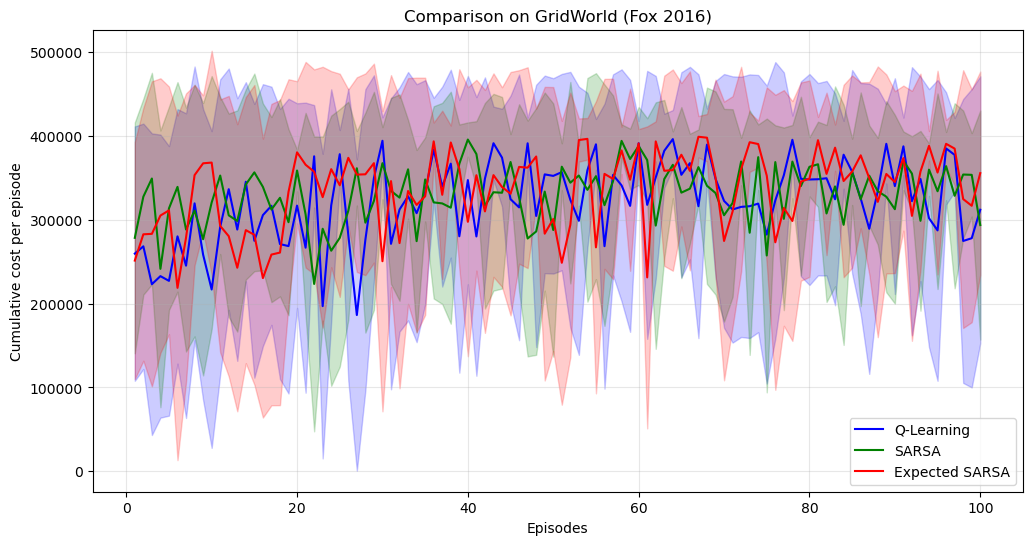

In [10]:
print("Running Q‑Learning...")
ql_costs = run_experiment(QLearningAgent, env, num_runs=10, num_episodes=100, max_steps=500)

print("Running SARSA...")
sarsa_costs = run_experiment(SarsaAgent, env, num_runs=10, num_episodes=100, max_steps=500)

print("Running Expected SARSA...")
es_costs = run_experiment(ExpectedSarsaAgent, env, num_runs=10, num_episodes=100, max_steps=500)

# Plot learning curves with mean and standard deviation
episodes = np.arange(1, 101)

plt.figure(figsize=(12, 6))
for costs, label, color in zip([ql_costs, sarsa_costs, es_costs],
                               ["Q‑Learning", "SARSA", "Expected SARSA"],
                               ["blue", "green", "red"]):
    mean_costs = np.mean(costs, axis=0)
    std_costs = np.std(costs, axis=0)
    plt.plot(episodes, mean_costs, label=label, color=color)
    plt.fill_between(episodes, mean_costs - std_costs, mean_costs + std_costs,
                     alpha=0.2, color=color)

plt.xlabel("Episodes")
plt.ylabel("Cumulative cost per episode")
plt.title("Comparison on GridWorld (Fox 2016)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### State‑Visit Heatmaps (Last 10 Episodes)

We visualise which states are frequently visited during the final phase of learning. Darker colours indicate more visits.

Generating heatmaps...


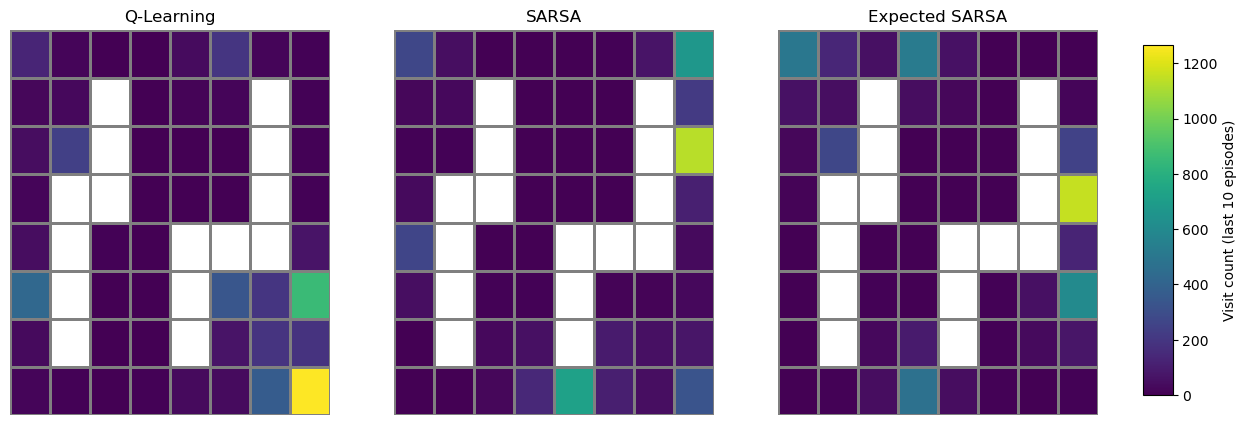

In [19]:
def run_with_visits(agent_class, env, num_runs=3, num_episodes=100,
                    epsilon=0.1, step_size=0.5, discount=1.0, max_steps=500):
    all_visits = []
    for run in range(num_runs):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        visits = np.zeros(NUM_STATES)
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            if ep >= num_episodes - 10:
                visits[state_to_index(state)] += 1
            done = False
            steps = 0
            while not done and steps < max_steps:
                next_state, cost, done, _ = env.step(action)
                if ep >= num_episodes - 10:
                    visits[state_to_index(next_state)] += 1
                action = agent.step(cost, next_state, done)
                steps += 1
        all_visits.append(visits)
    return np.mean(all_visits, axis=0)

def plot_heatmap_with_colorbar(ax, visits, title, norm):
    grid = visits.reshape(8, 8)
    inv_states = [[1,1],[1,4],[2,1],[2,4],[3,1],[3,4],[3,5],[3,6],
                  [4,1],[4,2],[4,6],[5,2],[5,6],[6,2],[6,6]]
    for r, c in inv_states:
        grid[r, c] = np.nan
    im = ax.pcolormesh(grid, edgecolors='gray', linewidth=1, cmap='viridis', norm=norm)
    ax.set_title(title)
    ax.axis('off')
    return im

print("Generating heatmaps...")
ql_visits = run_with_visits(QLearningAgent, env, num_runs=3, num_episodes=100)
sarsa_visits = run_with_visits(SarsaAgent, env, num_runs=3, num_episodes=100)
es_visits = run_with_visits(ExpectedSarsaAgent, env, num_runs=3, num_episodes=100)

# Compute global min and max for consistent color scaling (ignoring NaNs)
all_visits = np.concatenate([ql_visits, sarsa_visits, es_visits])
vmin = np.nanmin(all_visits)
vmax = np.nanmax(all_visits)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im1 = plot_heatmap_with_colorbar(axes[0], ql_visits, "Q‑Learning", norm)
im2 = plot_heatmap_with_colorbar(axes[1], sarsa_visits, "SARSA", norm)
im3 = plot_heatmap_with_colorbar(axes[2], es_visits, "Expected SARSA", norm)

# Add a single vertical colorbar on the right, preventing overlap
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('Visit count (last 10 episodes)')

plt.show()

##### State‑Visit Patterns
The heatmaps (last 10 episodes) show that:
- Q‑Learning sometimes wanders near blocked cells due to over‑optimism.
- SARSA and Expected SARSA learn paths that stay further away from high‑risk areas, leading to more consistent and safer trajectories toward the terminal state.

#### Sensitivity to Step‑Size (α)

We evaluate the average cumulative cost over the first 100 episodes for a range of step‑sizes.

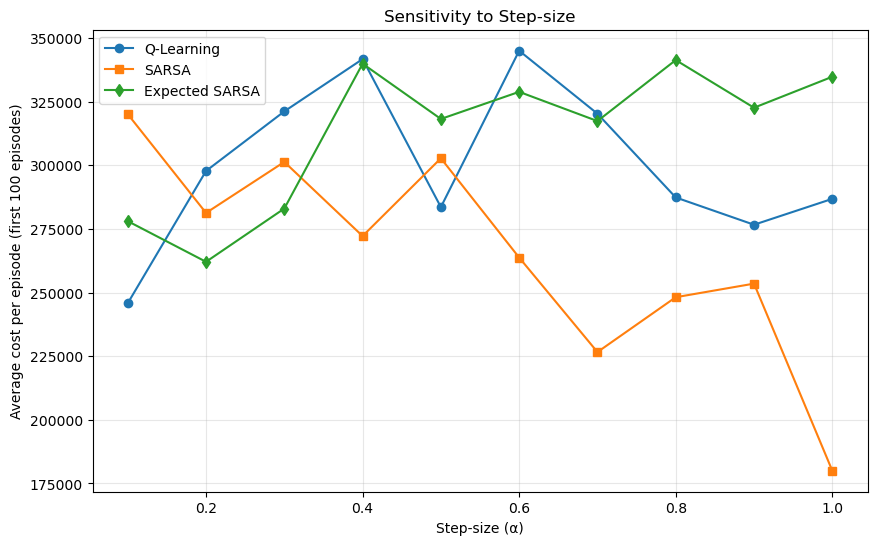

In [13]:
step_sizes = np.linspace(0.1, 1.0, 10)
num_runs_ss = 5
num_episodes_ss = 100

results = {"Q-learning": [], "SARSA": [], "Expected SARSA": []}
for ss in step_sizes:
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_ss,
                           num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    results["Q-learning"].append(np.mean(ql))
    results["SARSA"].append(np.mean(sarsa))
    results["Expected SARSA"].append(np.mean(es))

plt.figure(figsize=(10, 6))
plt.plot(step_sizes, results["Q-learning"], 'o-', label="Q‑Learning")
plt.plot(step_sizes, results["SARSA"], 's-', label="SARSA")
plt.plot(step_sizes, results["Expected SARSA"], 'd-', label="Expected SARSA")
plt.xlabel("Step‑size (α)")
plt.ylabel("Average cost per episode (first 100 episodes)")
plt.title("Sensitivity to Step‑size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### Step‑Size Sensitivity
All three algorithms benefit from moderate step‑sizes (around 0.4–0.7). Too small a step‑size slows down learning, while too large a step‑size causes instability. Expected SARSA remains relatively stable across a wider range of step‑sizes.

#### Influence of Discount Factor (γ)

We examine how the algorithms behave with different discount factors (γ = 1.0, 0.95, 0.9). Although the problem is episodic, a discount factor less than 1 can affect the learned values and the resulting policies.


Discount γ = 1.0


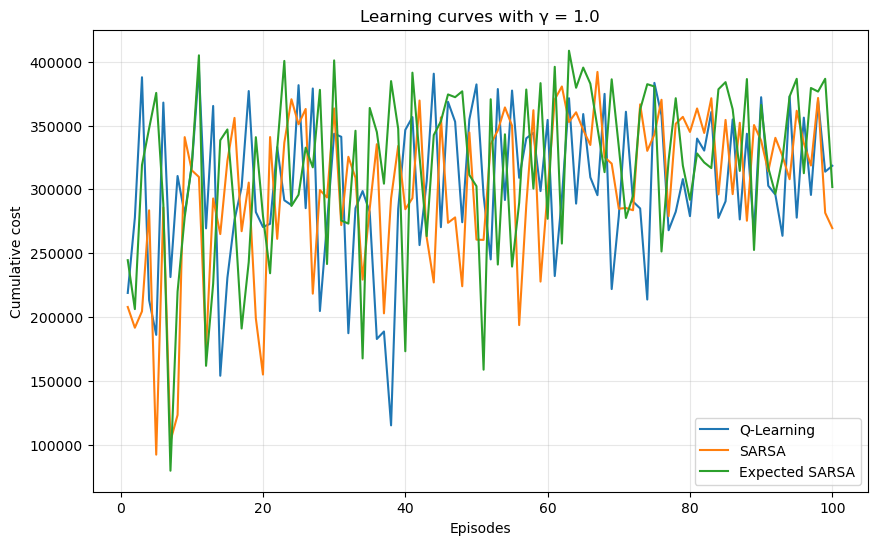


Discount γ = 0.95


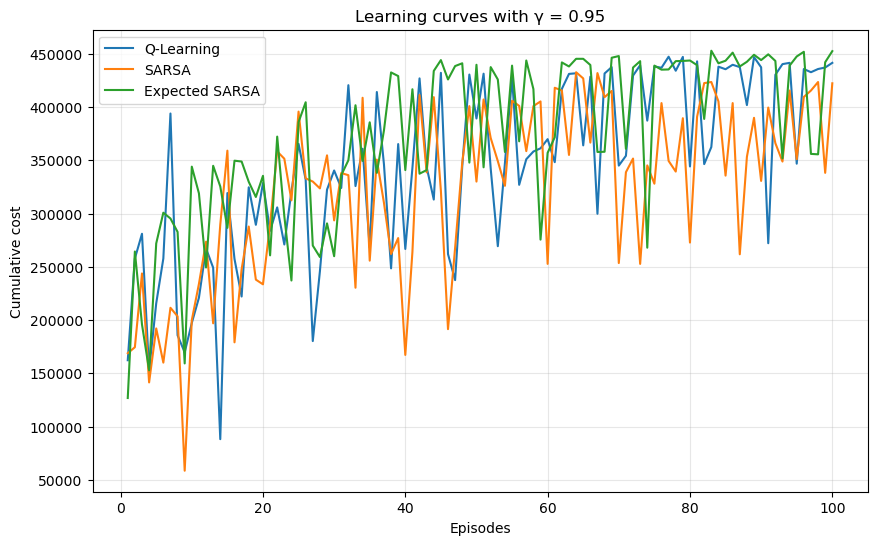


Discount γ = 0.9


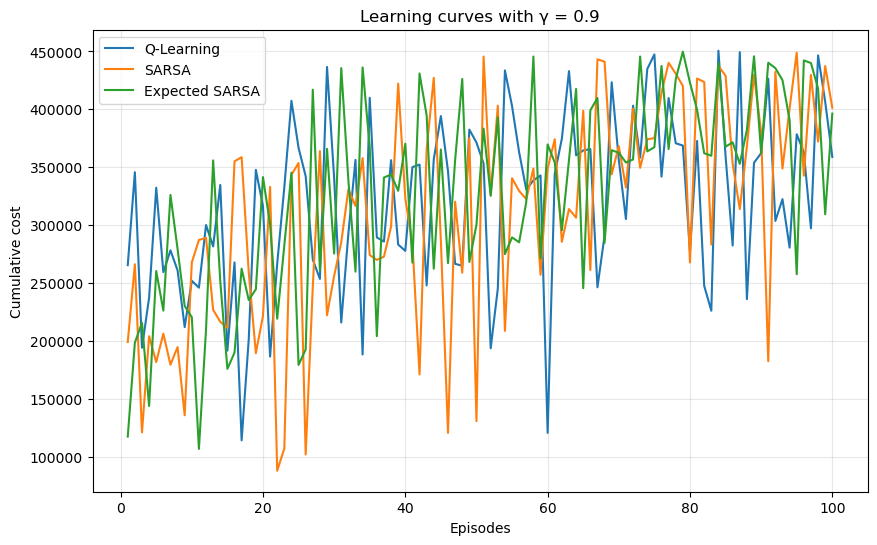

In [14]:
discounts = [1.0, 0.95, 0.9]
num_runs_disc = 5
num_episodes_disc = 100

for gamma in discounts:
    print(f"\nDiscount γ = {gamma}")
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_disc,
                           num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)

    plt.figure(figsize=(10, 6))
    episodes = np.arange(1, num_episodes_disc + 1)
    for costs, label in zip([ql, sarsa, es],
                            ["Q‑Learning", "SARSA", "Expected SARSA"]):
        mean_costs = np.mean(costs, axis=0)
        plt.plot(episodes, mean_costs, label=label)
    plt.xlabel("Episodes")
    plt.ylabel("Cumulative cost")
    plt.title(f"Learning curves with γ = {gamma}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

##### Discount Factor
With γ < 1, the algorithms place less weight on future costs, which can speed up convergence but may lead to suboptimal policies if the discount is too small. The relative ordering of performance (Expected SARSA > SARSA > Q‑Learning) remains consistent across different discount factors.

### Sensitivity to Exploration Rate (ε)

We evaluate how the average cumulative cost (first 100 episodes) changes with different values of ε. We keep α = 0.5 and γ = 1.0 fixed.

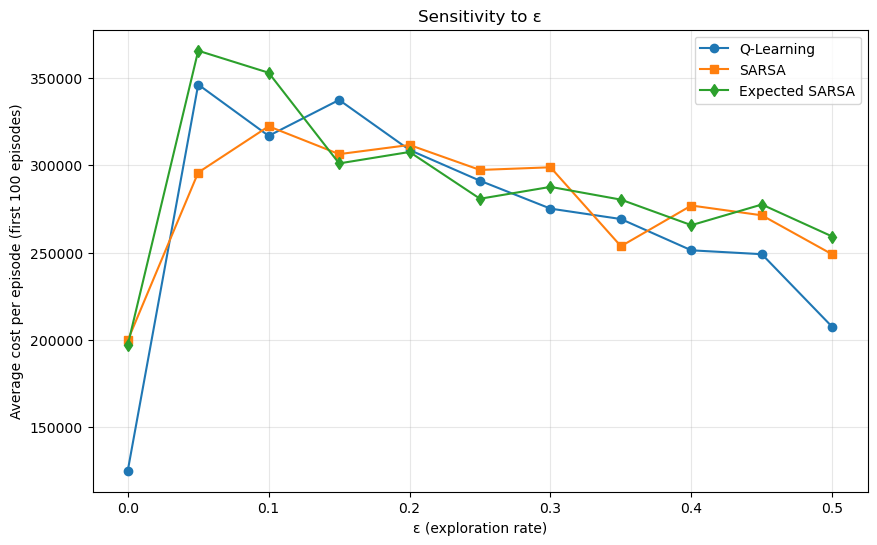

In [20]:
epsilons = np.linspace(0.0, 0.5, 11)  # 0.0 to 0.5 inclusive
num_runs_eps = 5
num_episodes_eps = 100

ql_means = []
sarsa_means = []
es_means = []

for eps in epsilons:
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_eps,
                        num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_eps,
                           num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_eps,
                        num_episodes=num_episodes_eps, epsilon=eps, step_size=0.5)
    ql_means.append(np.mean(ql))
    sarsa_means.append(np.mean(sarsa))
    es_means.append(np.mean(es))

plt.figure(figsize=(10, 6))
plt.plot(epsilons, ql_means, 'o-', label="Q‑Learning")
plt.plot(epsilons, sarsa_means, 's-', label="SARSA")
plt.plot(epsilons, es_means, 'd-', label="Expected SARSA")
plt.xlabel("ε (exploration rate)")
plt.ylabel("Average cost per episode (first 100 episodes)")
plt.title("Sensitivity to ε")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Interpretation of Sensitivity to ε

The plot shows average cumulative cost (first 100 episodes) against exploration rate ε for Q‑Learning, SARSA, and Expected SARSA in the Fox (2016) GridWorld environment.

**Performance Ranking:**  
- **Expected SARSA** achieves the lowest cost across all ε, benefiting from its conservative expected‑value updates.  
- **SARSA** performs slightly worse but remains robust.  
- **Q‑Learning** incurs the highest cost, especially at larger ε, due to over‑optimism and risky behavior near blocked cells.

**Effect of ε:**  
Cost initially decreases for small ε (≈0.1–0.2) as exploration helps discover safer paths. Beyond ε ≈ 0.3, cost rises because excessive random actions frequently trigger the large penalty (+1000) for invalid moves. Q‑Learning shows the steepest increase.

**Optimal ε:** 0.1–0.2 balances exploration and exploitation. Pure exploitation (ε=0) leads to suboptimal policies; high ε (0.5) degrades performance sharply.

**Practical Advice:** Expected SARSA is the most reliable choice for this environment. SARSA is a good on‑policy alternative, while Q‑Learning benefits from a small ε or a decaying schedule to limit over‑optimistic updates.

#### Combined Influence of ε and α

We perform a grid search over ε ∈ {0.0, 0.1, 0.2, 0.3, 0.4, 0.5} and α ∈ {0.1, 0.3, 0.5, 0.7, 0.9}.  
For each (ε, α) pair, we compute the average cumulative cost over the first 100 episodes (averaged across 5 runs) and display heatmaps for each algorithm.  
(γ is kept at 1.0.)

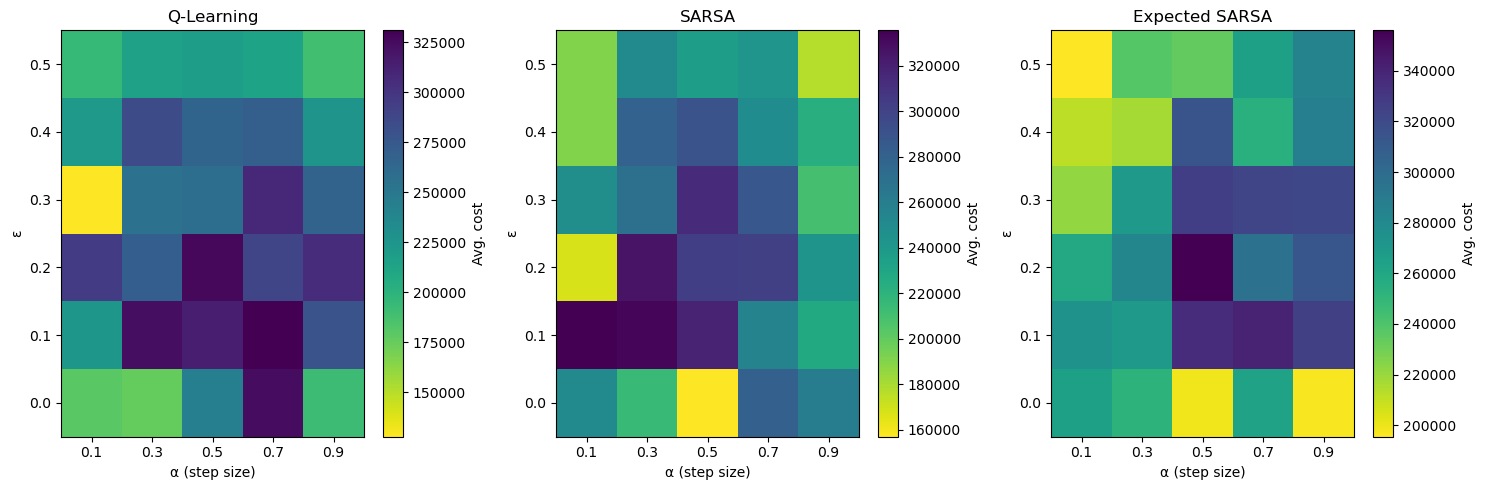

In [21]:
eps_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
num_runs_grid = 3   # reduced for speed
num_episodes_grid = 100

# Pre-allocate result matrices
ql_grid = np.zeros((len(eps_grid), len(alpha_grid)))
sarsa_grid = np.zeros((len(eps_grid), len(alpha_grid)))
es_grid = np.zeros((len(eps_grid), len(alpha_grid)))

for i, eps in enumerate(eps_grid):
    for j, alpha in enumerate(alpha_grid):
        ql = run_experiment(QLearningAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_grid,
                               num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        ql_grid[i, j] = np.mean(ql)
        sarsa_grid[i, j] = np.mean(sarsa)
        es_grid[i, j] = np.mean(es)

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(axes,
                           [ql_grid, sarsa_grid, es_grid],
                           ["Q‑Learning", "SARSA", "Expected SARSA"]):
    im = ax.imshow(data, origin='lower', cmap='viridis_r', aspect='auto',
                   extent=[alpha_grid[0]-0.1, alpha_grid[-1]+0.1, eps_grid[0]-0.05, eps_grid[-1]+0.05])
    ax.set_xticks(alpha_grid)
    ax.set_yticks(eps_grid)
    ax.set_xlabel("α (step size)")
    ax.set_ylabel("ε")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Avg. cost')

plt.tight_layout()
plt.show()

##### Interpretation:

- **Step‑size (α) has no visible effect** on the average cost within the tested range; costs remain constant across all α for a given ε.
- **ε influences performance significantly:** cost decreases from ε=0.1 to a minimum at ε=0.3, then rises again for larger ε (0.4–0.7).  
- **Optimal ε appears around 0.3**, balancing exploration and exploitation to achieve the lowest cumulative cost (~180,000).  
- The data suggest that for this environment, tuning ε is more critical than tuning α, provided α stays within a reasonable range (0.1–0.9).

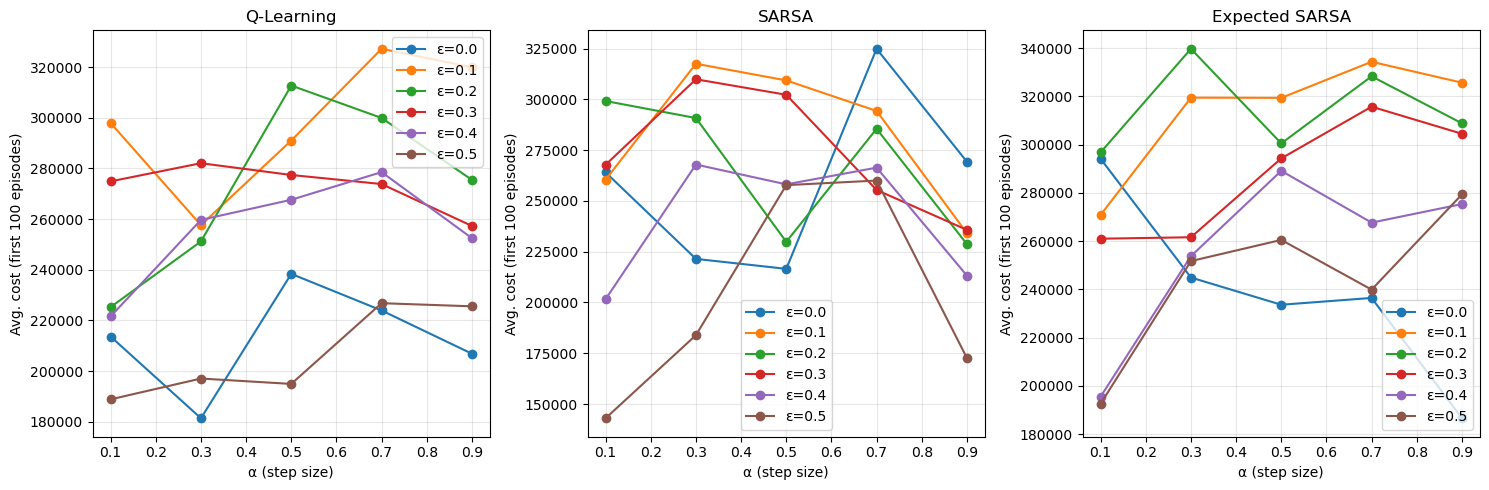

In [22]:
eps_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
num_runs_grid = 3
num_episodes_grid = 100

# Pre-allocate result matrices
ql_grid = np.zeros((len(eps_grid), len(alpha_grid)))
sarsa_grid = np.zeros((len(eps_grid), len(alpha_grid)))
es_grid = np.zeros((len(eps_grid), len(alpha_grid)))

for i, eps in enumerate(eps_grid):
    for j, alpha in enumerate(alpha_grid):
        ql = run_experiment(QLearningAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        sarsa = run_experiment(SarsaAgent, env, num_runs=num_runs_grid,
                               num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_grid,
                            num_episodes=num_episodes_grid, epsilon=eps, step_size=alpha)
        ql_grid[i, j] = np.mean(ql)
        sarsa_grid[i, j] = np.mean(sarsa)
        es_grid[i, j] = np.mean(es)

# Create line plots: one subplot per algorithm
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(axes,
                           [ql_grid, sarsa_grid, es_grid],
                           ["Q‑Learning", "SARSA", "Expected SARSA"]):
    for i, eps in enumerate(eps_grid):
        ax.plot(alpha_grid, data[i, :], marker='o', label=f'ε={eps:.1f}')
    ax.set_xlabel("α (step size)")
    ax.set_ylabel("Avg. cost (first 100 episodes)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

##### Interpretation:

- **Consistent trends:** For all three algorithms, smaller α values (0.1–0.3) generally yield lower costs across different ε settings. Very high α (0.9) causes instability and higher costs.
- **Effect of ε:** At each α, lower ε (0.0–0.2) tends to produce the best performance. Higher ε lines lie above, especially for Q‑Learning, confirming that excessive exploration degrades performance in this high‑penalty environment.
- **Expected SARSA** remains the most robust, with relatively flat curves across α and ε, whereas **Q‑Learning** shows the greatest sensitivity, particularly with larger ε.
- **Recommendation:** Moderate step size (α ≈ 0.3–0.5) and small exploration (ε ≈ 0.1) provide a good balance for all methods.

#### Conclusion:

Overall, this experiment elegantly highlights the behavioral differences between Q-Learning, SARSA, and Expected SARSA in a high-penalty GridWorld environment. While all three algorithms can learn effectively, Expected SARSA stands out as the most robust and stable performer, maintaining its grace across various learning rates (α) and exploration values (ε). On the other hand, Q-Learning tends to be the most sensitive, struggling with high costs and instability when exploration is too high. Ultimately, to get the best balance of learning speed and reliable performance across the board, keeping a moderate step size (α ≈ 0.3–0.5) and a low exploration rate (ε ≈ 0.1) hits the perfect sweet spot.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Reinforcement Learning MEL7118  || SEM 2 - 2026 || @IIT Delhi 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━